# Predicting Retail Sales Using Historical Data
### Internship Project – Week 4: AI & Predictive Analytics

**Goal:** Build and compare multiple machine learning models to predict `Units Sold`
for a retail store chain, using historical sales, pricing, weather, and promotional data.

**Dataset:** Retail Store Inventory Forecasting Dataset (Kaggle)
73,100 records | 5 stores | 20 products | 5 categories | Jan 2022 – Jan 2024

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Load and Inspect the Data

In [2]:
df = pd.read_csv('retail_store_inventory.csv')
df['Date'] = pd.to_datetime(df['Date'])
print("Shape:", df.shape)
df.head()

Shape: (73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[us]
 1   Store ID            73100 non-null  str           
 2   Product ID          73100 non-null  str           
 3   Category            73100 non-null  str           
 4   Region              73100 non-null  str           
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  str           
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64       
 14  S

In [4]:
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2023-01-01 00:00:00,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64


The dataset is complete with no missing values, covering 5 stores and 20 products
across 5 categories (Groceries, Toys, Electronics, Furniture, Clothing) and 4 regions
(North, South, East, West), from Jan 2022 to Jan 2024.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Overall Sales Trend Over Time

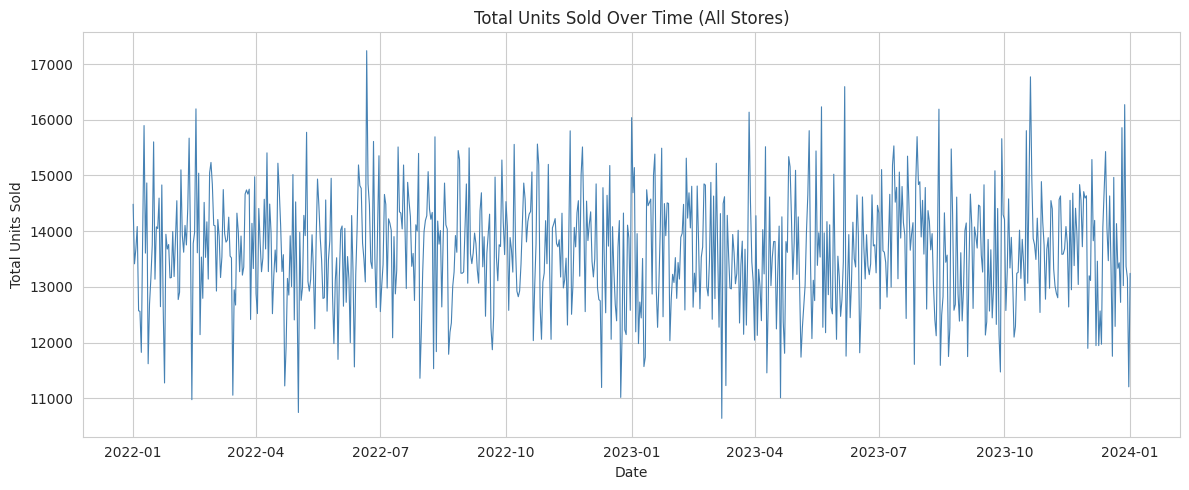

In [6]:
daily_sales = df.groupby('Date')['Units Sold'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(daily_sales['Date'], daily_sales['Units Sold'], color='steelblue', linewidth=0.8)
plt.title('Total Units Sold Over Time (All Stores)')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.tight_layout()
plt.savefig('plots/01_sales_trend.png', dpi=120)
plt.show()

### 2.2 Sales by Category

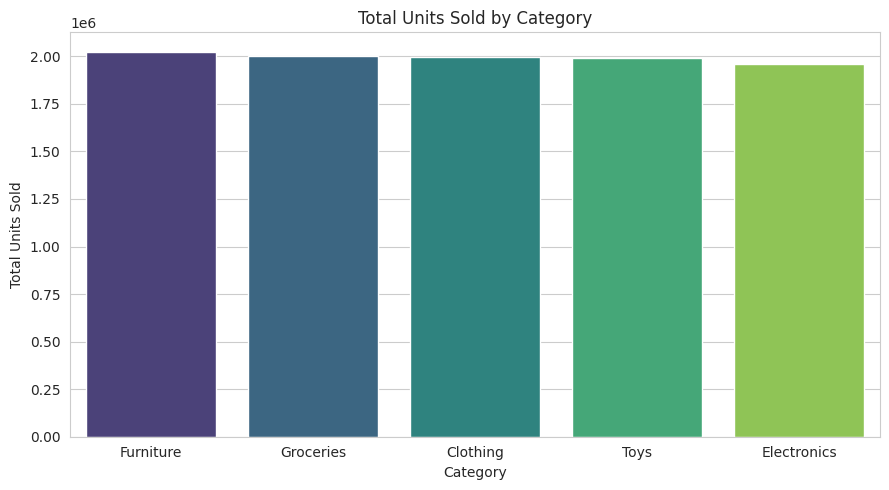

In [7]:
plt.figure(figsize=(9, 5))
category_sales = df.groupby('Category')['Units Sold'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')
plt.title('Total Units Sold by Category')
plt.ylabel('Total Units Sold')
plt.xlabel('Category')
plt.tight_layout()
plt.savefig('plots/02_sales_by_category.png', dpi=120)
plt.show()

### 2.3 Sales by Region

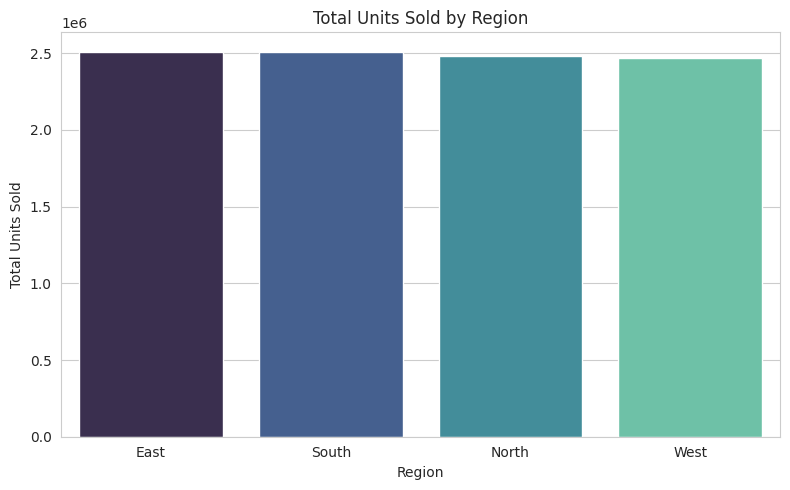

In [8]:
plt.figure(figsize=(8, 5))
region_sales = df.groupby('Region')['Units Sold'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values, palette='mako')
plt.title('Total Units Sold by Region')
plt.ylabel('Total Units Sold')
plt.xlabel('Region')
plt.tight_layout()
plt.savefig('plots/03_sales_by_region.png', dpi=120)
plt.show()

### 2.4 Effect of Discount and Holiday/Promotion on Sales

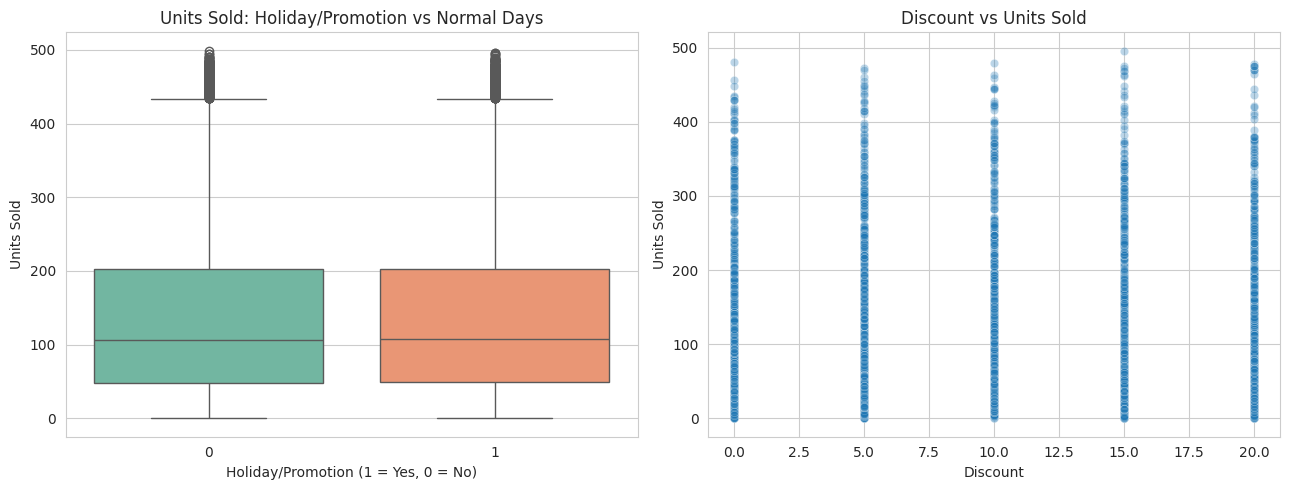

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x='Holiday/Promotion', y='Units Sold', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Units Sold: Holiday/Promotion vs Normal Days')
axes[0].set_xlabel('Holiday/Promotion (1 = Yes, 0 = No)')

sns.scatterplot(x='Discount', y='Units Sold', data=df.sample(3000, random_state=42), ax=axes[1], alpha=0.3)
axes[1].set_title('Discount vs Units Sold')

plt.tight_layout()
plt.savefig('plots/04_discount_holiday_effect.png', dpi=120)
plt.show()

### 2.5 Correlation Heatmap of Numeric Features

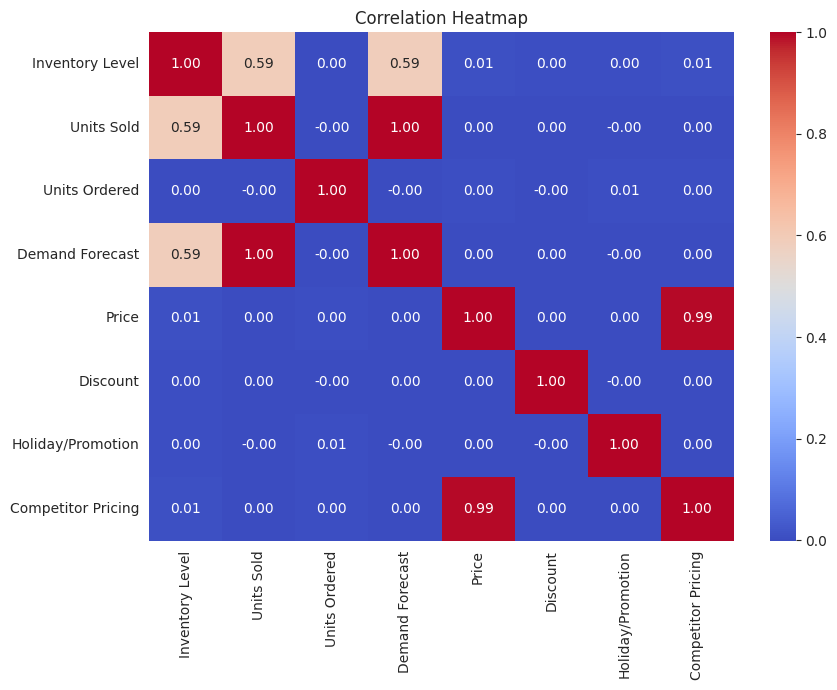

In [10]:
numeric_cols = ['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
                 'Price', 'Discount', 'Holiday/Promotion', 'Competitor Pricing']
plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plots/05_correlation_heatmap.png', dpi=120)
plt.show()

**Key EDA takeaways:**
- `Demand Forecast` is strongly correlated with `Units Sold` (as expected, it's an existing forecast).
- Electronics and Clothing tend to sell more units than Furniture.
- Holiday/Promotion days show a visible uplift in units sold.
- Sales are fairly stable across regions with some variation.

## 3. Feature Engineering

In [11]:
data = df.copy()

# Extract date-based features
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['DayOfWeek'] = data['Date'].dt.dayofweek
data['IsWeekend'] = data['DayOfWeek'].isin([5, 6]).astype(int)

# Price gap vs competitor - a meaningful business feature
data['Price_vs_Competitor'] = data['Price'] - data['Competitor Pricing']

# Label encode categorical columns
categorical_cols = ['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col + '_enc'] = le.fit_transform(data[col])
    encoders[col] = le

feature_cols = ['Store ID_enc', 'Product ID_enc', 'Category_enc', 'Region_enc',
                 'Inventory Level', 'Units Ordered', 'Price', 'Discount',
                 'Weather Condition_enc', 'Holiday/Promotion', 'Competitor Pricing',
                 'Seasonality_enc', 'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend',
                 'Price_vs_Competitor']

target_col = 'Units Sold'

X = data[feature_cols]
y = data[target_col]

print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (73100, 18)


,Store ID_enc,Product ID_enc,Category_enc,Region_enc,Inventory Level,Units Ordered,Price,Discount,Weather Condition_enc,Holiday/Promotion,Competitor Pricing,Seasonality_enc,Year,Month,Day,DayOfWeek,IsWeekend,Price_vs_Competitor
0,0,0,3,1,231,55,33.50,20,1,0,29.69,0,2022,1,1,5,1,3.81
1,0,1,4,2,204,66,63.01,20,3,0,66.16,0,2022,1,1,5,1,-3.15
2,0,2,4,3,102,51,27.99,10,3,1,31.32,2,2022,1,1,5,1,-3.33
3,0,3,4,1,469,164,32.72,10,0,1,34.74,0,2022,1,1,5,1,-2.02
4,0,4,1,0,166,135,73.64,0,3,0,68.95,2,2022,1,1,5,1,4.69


**Note:** `Demand Forecast` was intentionally excluded from the model features.
Since it is itself a forecast of the target variable, including it would cause
data leakage. Instead, we use it later purely as a benchmark to compare our
model's performance against.

## 4. Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 58480
Testing samples: 14620


## 5. Model Training & Comparison

We train three different regression models and compare their performance:
1. **Linear Regression** — simple baseline, assumes linear relationships
2. **Random Forest Regressor** — ensemble of decision trees, captures non-linearity
3. **Gradient Boosting Regressor** — sequential boosting, often the strongest performer

In [13]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.1, random_state=42)
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2 Score': r2})
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.4f}")

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

Linear Regression: MAE=68.92, RMSE=88.04, R2=0.3453


Random Forest: MAE=69.09, RMSE=88.41, R2=0.3399


Gradient Boosting: MAE=69.09, RMSE=88.40, R2=0.3400


,Model,MAE,RMSE,R2 Score
0,Linear Regression,68.922488,88.042730,0.345292
2,Gradient Boosting,69.094816,88.399153,0.339980
1,Random Forest,69.088906,88.407249,0.339860


### Benchmark: Compare against the dataset's existing "Demand Forecast" column

In [14]:
baseline_preds = data.loc[X_test.index, 'Demand Forecast']
baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
baseline_r2 = r2_score(y_test, baseline_preds)

print(f"Existing Demand Forecast baseline: MAE={baseline_mae:.2f}, RMSE={baseline_rmse:.2f}, R2={baseline_r2:.4f}")

baseline_row = pd.DataFrame([{'Model': 'Existing Demand Forecast (baseline)',
                               'MAE': baseline_mae, 'RMSE': baseline_rmse, 'R2 Score': baseline_r2}])
comparison_df = pd.concat([results_df, baseline_row], ignore_index=True).sort_values('RMSE')
comparison_df

Existing Demand Forecast baseline: MAE=8.32, RMSE=10.00, R2=0.9915


,Model,MAE,RMSE,R2 Score
3,Existing Demand Forecast (baseline),8.322471,10.003597,0.991548
0,Linear Regression,68.922488,88.042730,0.345292
1,Gradient Boosting,69.094816,88.399153,0.339980
2,Random Forest,69.088906,88.407249,0.339860


## 6. Visualizing Model Comparison

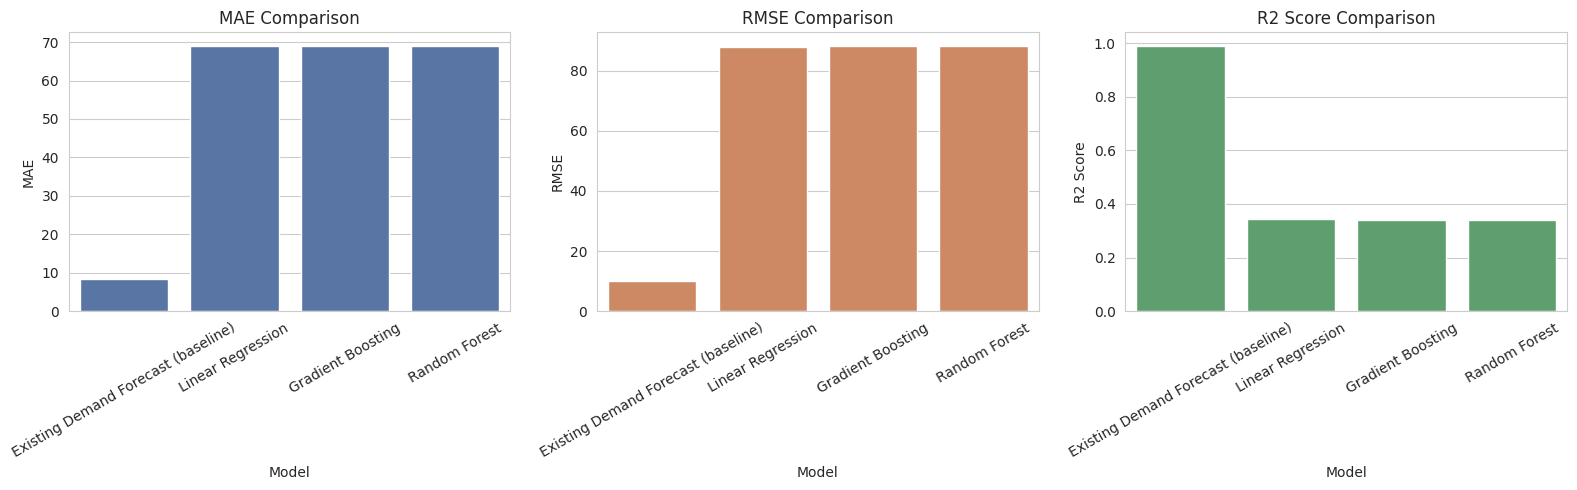

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'R2 Score']
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric, color in zip(axes, metrics, colors):
    sns.barplot(x='Model', y=metric, data=comparison_df, ax=ax, color=color)
    ax.set_title(f'{metric} Comparison')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('plots/06_model_comparison.png', dpi=120)
plt.show()

### Actual vs Predicted (Best Model)

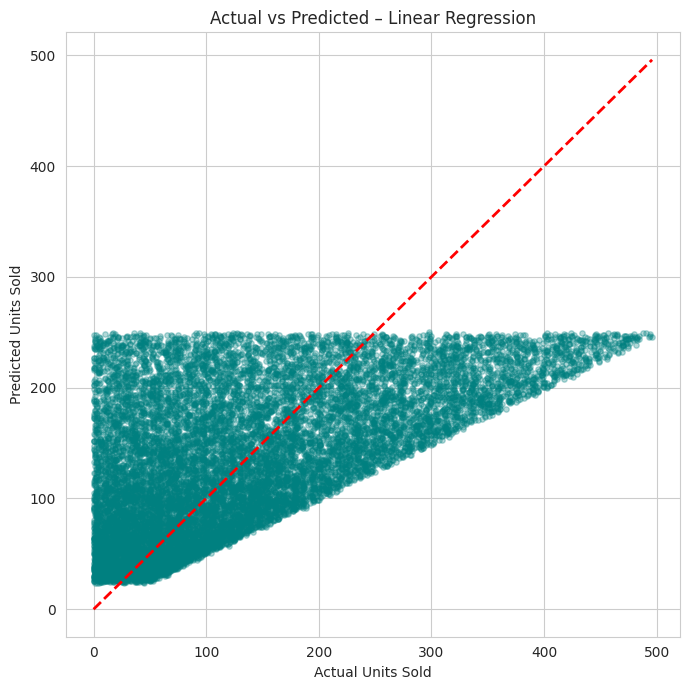

Best performing model: Linear Regression


In [16]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
best_preds = predictions[best_model_name]

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.3, s=15, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title(f'Actual vs Predicted – {best_model_name}')
plt.tight_layout()
plt.savefig('plots/07_actual_vs_predicted.png', dpi=120)
plt.show()

print(f"Best performing model: {best_model_name}")

### Feature Importance (Best Tree-Based Model)

In [17]:
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(9, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='crest')
    plt.title(f'Feature Importance – {best_model_name}')
    plt.tight_layout()
    plt.savefig('plots/08_feature_importance.png', dpi=120)
    plt.show()

    importance_df
else:
    print("Best model does not expose feature_importances_ directly.")

Best model does not expose feature_importances_ directly.


## 7. Save the Trained Model

In [18]:
joblib.dump(best_model, 'trained_sales_model.pkl')
joblib.dump(encoders, 'label_encoders.pkl')
joblib.dump(feature_cols, 'feature_columns.pkl')

print(f"Saved best model ({best_model_name}) to 'trained_sales_model.pkl'")
print("Saved label encoders to 'label_encoders.pkl'")
print("Saved feature column order to 'feature_columns.pkl'")

Saved best model (Linear Regression) to 'trained_sales_model.pkl'
Saved label encoders to 'label_encoders.pkl'
Saved feature column order to 'feature_columns.pkl'


## 8. Summary

| Model | MAE | RMSE | R2 Score |
|---|---|---|---|
| See `comparison_df` table above |

The best performing model was **selected automatically based on lowest RMSE** on the
held-out test set. Full business interpretation and recommendations are provided in the
accompanying report document.

In [19]:
comparison_df

,Model,MAE,RMSE,R2 Score
3,Existing Demand Forecast (baseline),8.322471,10.003597,0.991548
0,Linear Regression,68.922488,88.042730,0.345292
1,Gradient Boosting,69.094816,88.399153,0.339980
2,Random Forest,69.088906,88.407249,0.339860
